# Protein-Membrane MD Analysis (MDAnalysis)

Analyses for NAMD-generated trajectories (`.psf` + `.dcd`):

1. **Contact probability** per protein residue vs. a lipid group
2. **Residence time** via survival-probability autocorrelation + double-exponential fit
3. **Orientation** of a protein vector relative to the membrane normal
4. **Lipid contact enrichment** relative to the bulk membrane composition

All results are written out as `.csv` files for downstream plotting/sharing.

```
pip install MDAnalysis numpy scipy pandas matplotlib --break-system-packages
```

In [1]:
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit
import MDAnalysis as mda
from MDAnalysis.analysis.distances import distance_array
import matplotlib.pyplot as plt

%matplotlib inline

## Load trajectory

Edit the paths below to point to your NAMD `.psf`/`.dcd` files.

In [2]:
PSF = "step5_input.psf"
DCD = "stride10.dcd"

# time (ps) between consecutive frames in the DCD -- set this to your
# actual NAMD dcdfreq * timestep, needed for residence-time units to be correct
DT_PS = 1000.0

u = mda.Universe(PSF, DCD)
print(f"Loaded {len(u.trajectory)} frames, {len(u.atoms)} atoms")

Loaded 500 frames, 465615 atoms


/Users/artembonchuk/anaconda3/lib/python3.11/site-packages/MDAnalysis/coordinates/DCD.py:171: DeprecationWarning: DCDReader currently makes independent timesteps by copying self.ts while other readers update self.ts inplace. This behavior will be changed in 3.0 to be the same as other readers. Read more at https://github.com/MDAnalysis/mdanalysis/issues/3889 to learn if this change in behavior might affect you.
  warnings.warn("DCDReader currently makes independent timesteps"


## 1. Contact probability

For each protein residue, the fraction of frames in which any atom of that residue is within `cutoff` Å of the chosen lipid selection.

In [3]:
def contact_probability(universe, protein_sel, lipid_sel, cutoff=5.0, step=1):
    """
    Returns a pandas DataFrame with columns: resid, resname, contact_probability
    """
    protein = universe.select_atoms(protein_sel)
    lipids = universe.select_atoms(lipid_sel)
    residues = protein.residues

    contact_counts = np.zeros(len(residues))
    n_frames = 0

    for ts in universe.trajectory[::step]:
        n_frames += 1
        for i, res in enumerate(residues):
            d = distance_array(res.atoms.positions, lipids.positions,
                                box=universe.dimensions)
            if d.size and d.min() <= cutoff:
                contact_counts[i] += 1

    probs = contact_counts / n_frames
    df = pd.DataFrame({
        "resid": [res.resid for res in residues],
        "resname": [res.resname for res in residues],
        "contact_probability": probs,
    })
    return df

In [4]:
print(sorted(set(u.segments.segids))) 

['IONS', 'MEMB', 'PROA', 'PROB', 'TIP3']


In [5]:
contact_df = contact_probability(
    u,
    protein_sel="segid PROA",
    lipid_sel="segid MEMB",
    cutoff=5.0,
    step=10,
)

contact_df.to_csv("contact_probability_per_residue_chainA.csv", index=False)
contact_df.sort_values("contact_probability", ascending=False).head(10)

,resid,resname,contact_probability
183,3432,LEU,0.66
182,3431,LEU,0.54
41,3290,PRO,0.24
40,3289,GLY,0.22
90,3339,LYS,0.20
181,3430,ARG,0.20
39,3288,PRO,0.20
106,3355,PRO,0.18
42,3291,ASP,0.18
43,3292,ARG,0.18


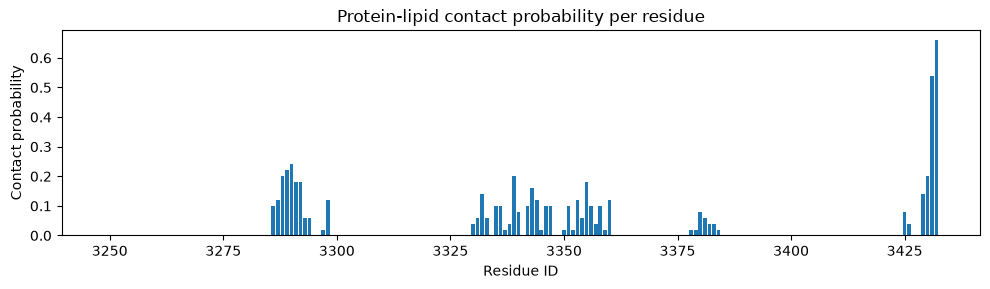

In [6]:
plt.figure(figsize=(10, 3))
plt.bar(contact_df["resid"], contact_df["contact_probability"])
plt.xlabel("Residue ID")
plt.ylabel("Contact probability")
plt.title("Protein-lipid contact probability per residue")
plt.tight_layout()
plt.savefig("contact_probability_per_residue_chainA.svg", format="svg")
plt.show()

In [7]:
contact_df = contact_probability(
    u,
    protein_sel="segid PROB",
    lipid_sel="segid MEMB",
    cutoff=5.0,
    step=10,
)

contact_df.to_csv("contact_probability_per_residue_chainB.csv", index=False)
contact_df.sort_values("contact_probability", ascending=False).head(10)

,resid,resname,contact_probability
255,256,LEU,1.0
247,248,ALA,1.0
306,307,LYS,1.0
246,247,LYS,1.0
248,249,VAL,1.0
251,252,PRO,1.0
240,241,PHE,1.0
239,240,LEU,1.0
238,239,HSD,1.0
237,238,LYS,1.0


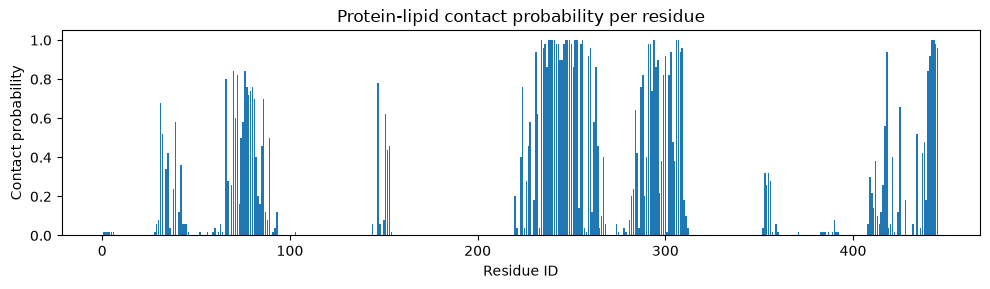

In [8]:
plt.figure(figsize=(10, 3))
plt.bar(contact_df["resid"], contact_df["contact_probability"])
plt.xlabel("Residue ID")
plt.ylabel("Contact probability")
plt.title("Protein-lipid contact probability per residue")
plt.tight_layout()
plt.savefig("contact_probability_per_residue_chainB.svg", format="svg")
plt.show()

## 2. Residence time

Builds a binary contact time series between a reference selection (e.g. one residue) and a target lipid group, then computes the survival-probability autocorrelation S(τ) and fits a double exponential to extract fast (rattling) and slow (genuine binding) timescales.

In [9]:
def binary_contact_series(universe, ref_sel, target_sel, cutoff=5.0, step=1):
    ref = universe.select_atoms(ref_sel)
    tgt = universe.select_atoms(target_sel)

    series = []
    for ts in universe.trajectory[::step]:
        d = distance_array(ref.positions, tgt.positions, box=universe.dimensions)
        series.append(1 if (d.size and d.min() <= cutoff) else 0)
    return np.array(series, dtype=float)


def survival_probability(s):
    n = len(s)
    mean_s = s.mean()
    if mean_s == 0:
        return np.zeros(n)
    f = np.fft.fft(s, n=2 * n)
    acf = np.fft.ifft(f * np.conjugate(f))[:n].real
    acf /= (n - np.arange(n))
    S = acf / mean_s
    return S / S[0]


def double_exp(t, a, tau1, tau2):
    return a * np.exp(-t / tau1) + (1 - a) * np.exp(-t / tau2)


def _fit_residence_time(s, tau_axis):
    """Fit double exponential to one residue's survival curve. Returns fit dict."""
    fit_params = {"mean_occupancy": s.mean(), "tau_fast_ps": None,
                  "tau_slow_ps": None, "amplitude_a": None, "fit_success": False}
    if s.mean() == 0:
        return fit_params
    try:
        S = survival_probability(s)
        popt, _ = curve_fit(
            double_exp, tau_axis, S,
            p0=[0.5, tau_axis[max(1, len(tau_axis)//20)], tau_axis[-1] / 5],
            maxfev=20000,
        )
        a, tau1, tau2 = popt
        tau_fast, tau_slow = sorted([tau1, tau2])
        fit_params.update({"tau_fast_ps": tau_fast, "tau_slow_ps": tau_slow,
                            "amplitude_a": a, "fit_success": True})
    except RuntimeError:
        pass
    return fit_params


def residence_time_per_residue(universe, protein_sel, target_sel, cutoff=5.0,
                                step=1, dt_ps=1.0):
    """
    Compute residence time of `target_sel` (e.g. a lipid headgroup) at each
    residue of `protein_sel`, via per-residue survival-probability decay.

    Returns
    -------
    summary_df : one row per residue -- resid, resname, mean_occupancy,
                 tau_fast_ps, tau_slow_ps, amplitude_a, fit_success
    curves_df  : long format -- resid, tau_ps, S  (all residues' survival curves,
                 for plotting any individual residue's decay afterwards)
    """
    protein = universe.select_atoms(protein_sel)
    residues = protein.residues

    summary_rows = []
    curve_rows = []

    for res in residues:
        ref_sel = f"protein and segid {res.segid} and resid {res.resid}"
        s = binary_contact_series(universe, ref_sel, target_sel, cutoff, step)
        tau_axis = np.arange(len(s)) * dt_ps * step

        fit_params = _fit_residence_time(s, tau_axis)
        summary_rows.append({
            "resid": res.resid,
            "resname": res.resname,
            "segid": res.segid,
            **fit_params,
        })

        if s.mean() > 0:
            S = survival_probability(s)
            for t, sval in zip(tau_axis, S):
                curve_rows.append({"resid": res.resid, "segid": res.segid,
                                    "tau_ps": t, "S": sval})

    summary_df = pd.DataFrame(summary_rows)
    curves_df = pd.DataFrame(curve_rows)
    return summary_df, curves_df

In [10]:
residence_summary_df, residence_curves_df = residence_time_per_residue(
    u,
    protein_sel="segid PROA",
    target_sel="segid MEMB",
    cutoff=5.0,
    step=1,
    dt_ps=DT_PS,
)

residence_summary_df.to_csv("residence_time_per_residue_chainA.csv", index=False)
residence_curves_df.to_csv("residence_time_survival_curves_chainA.csv", index=False)

residence_summary_df.sort_values("tau_slow_ps", ascending=False).head(10)

/var/folders/jm/05ch517x2v976nq1w0l5znn40000gn/T/ipykernel_36603/431927563.py:36: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, _ = curve_fit(
/var/folders/jm/05ch517x2v976nq1w0l5znn40000gn/T/ipykernel_36603/431927563.py:25: RuntimeWarning: overflow encountered in exp
  return a * np.exp(-t / tau1) + (1 - a) * np.exp(-t / tau2)


,resid,resname,segid,mean_occupancy,tau_fast_ps,tau_slow_ps,amplitude_a,fit_success
183,3432,LEU,PROA,0.638,7135.252547,1.237807e+13,0.316106,True
182,3431,LEU,PROA,0.464,9706.693634,7.211571e+05,0.432133,True
179,3428,TRP,PROA,0.010,38.680284,2.308742e+05,0.985801,True
81,3330,THR,PROA,0.024,4995.025593,1.578222e+05,0.988223,True
180,3429,THR,PROA,0.160,13521.602350,1.544396e+05,0.715683,True
111,3360,GLN,PROA,0.082,24098.658286,1.012114e+05,1.023863,True
181,3430,ARG,PROA,0.200,864.668600,9.460624e+04,0.349027,True
83,3332,SER,PROA,0.120,7418.814382,8.211743e+04,0.611392,True
110,3359,THR,PROA,0.014,1999.484160,7.585864e+04,0.973852,True
51,3300,ALA,PROA,0.002,26.178468,7.021036e+04,1.000000,True


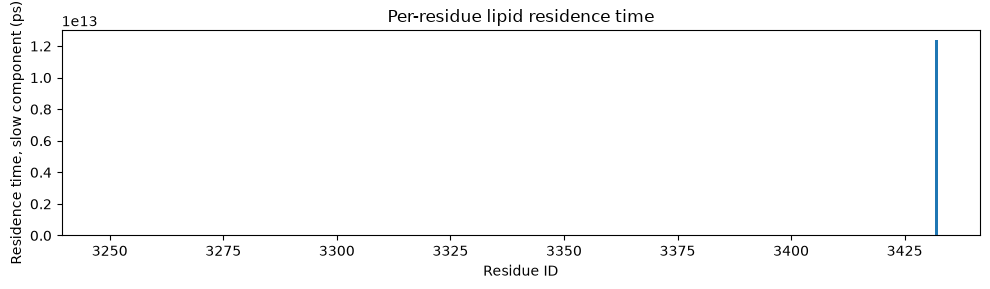

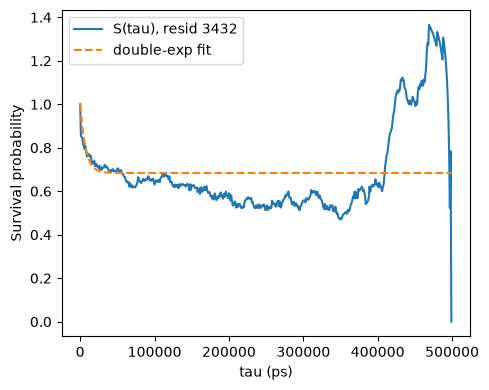

In [11]:
# Bar plot: slow-component residence time per residue (the biologically meaningful timescale)
plt.figure(figsize=(10, 3))
plt.bar(residence_summary_df["resid"], residence_summary_df["tau_slow_ps"].fillna(0))
plt.xlabel("Residue ID")
plt.ylabel("Residence time, slow component (ps)")
plt.title("Per-residue lipid residence time")
plt.tight_layout()
plt.show()

# Example: overlay the survival curve + fit for a single residue of interest
example_resid = residence_summary_df.sort_values("tau_slow_ps", ascending=False).iloc[0]["resid"]
sub = residence_curves_df[residence_curves_df["resid"] == example_resid]
row = residence_summary_df[residence_summary_df["resid"] == example_resid].iloc[0]

plt.figure(figsize=(5, 4))
plt.plot(sub["tau_ps"], sub["S"], label=f"S(tau), resid {example_resid}")
if row["fit_success"]:
    fit_curve = double_exp(sub["tau_ps"], row["amplitude_a"], row["tau_fast_ps"], row["tau_slow_ps"])
    plt.plot(sub["tau_ps"], fit_curve, "--", label="double-exp fit")
plt.xlabel("tau (ps)")
plt.ylabel("Survival probability")
plt.legend()
plt.tight_layout()
plt.savefig("residence_time_per_residue_chainA.svg", format="svg")
plt.show()

In [13]:
residence_summary_df, residence_curves_df = residence_time_per_residue(
    u,
    protein_sel="segid PROB",
    target_sel="segid MEMB",
    cutoff=5.0,
    step=1,
    dt_ps=DT_PS,
)

residence_summary_df.to_csv("residence_time_per_residue_chainB.csv", index=False)
residence_curves_df.to_csv("residence_time_survival_curves_chainB.csv", index=False)

residence_summary_df.sort_values("tau_slow_ps", ascending=False).head(10)

/var/folders/jm/05ch517x2v976nq1w0l5znn40000gn/T/ipykernel_36603/431927563.py:25: RuntimeWarning: overflow encountered in exp
  return a * np.exp(-t / tau1) + (1 - a) * np.exp(-t / tau2)
/var/folders/jm/05ch517x2v976nq1w0l5znn40000gn/T/ipykernel_36603/431927563.py:36: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, _ = curve_fit(


,resid,resname,segid,mean_occupancy,tau_fast_ps,tau_slow_ps,amplitude_a,fit_success
308,309,ASP,PROB,0.984,46.963972,6.954511e+14,0.012015,True
291,292,LYS,PROB,0.968,7.869356,4.738159e+14,0.018281,True
235,236,THR,PROB,0.982,34.768131,2.543759e+14,0.015419,True
299,300,LYS,PROB,0.942,23.654733,2.188552e+14,0.046586,True
243,244,GLN,PROB,0.938,34.169163,2.013094e+14,0.035917,True
290,291,ALA,PROB,0.960,4.101089,1.867682e+14,0.026170,True
444,445,GLY,PROB,0.946,23.703767,1.142380e+14,0.035204,True
230,231,GLU,PROB,0.938,31.578699,1.043952e+14,0.033148,True
244,245,SER,PROB,0.914,901.836392,9.641611e+13,0.062832,True
443,444,LYS,PROB,0.992,39.792531,9.458089e+13,0.007698,True


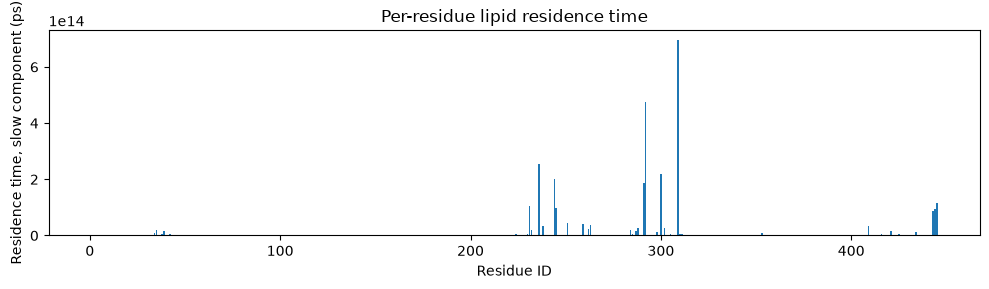

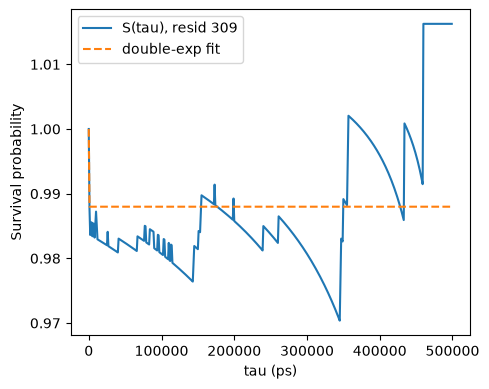

In [14]:
# Bar plot: slow-component residence time per residue (the biologically meaningful timescale)
plt.figure(figsize=(10, 3))
plt.bar(residence_summary_df["resid"], residence_summary_df["tau_slow_ps"].fillna(0))
plt.xlabel("Residue ID")
plt.ylabel("Residence time, slow component (ps)")
plt.title("Per-residue lipid residence time")
plt.tight_layout()
plt.show()

# Example: overlay the survival curve + fit for a single residue of interest
example_resid = residence_summary_df.sort_values("tau_slow_ps", ascending=False).iloc[0]["resid"]
sub = residence_curves_df[residence_curves_df["resid"] == example_resid]
row = residence_summary_df[residence_summary_df["resid"] == example_resid].iloc[0]

plt.figure(figsize=(5, 4))
plt.plot(sub["tau_ps"], sub["S"], label=f"S(tau), resid {example_resid}")
if row["fit_success"]:
    fit_curve = double_exp(sub["tau_ps"], row["amplitude_a"], row["tau_fast_ps"], row["tau_slow_ps"])
    plt.plot(sub["tau_ps"], fit_curve, "--", label="double-exp fit")
plt.xlabel("tau (ps)")
plt.ylabel("Survival probability")
plt.legend()
plt.tight_layout()
plt.savefig("residence_time_per_residue_chainB.svg", format="svg")
plt.show()

## 3. Orientation relative to the membrane normal

Angle θ(t) between a protein-defined vector (e.g. a TM helix axis, via two Cα atoms) and the membrane normal (default: z-axis). Produces a per-frame trace and a sin(θ)-weighted probability density (proper solid-angle normalization), plus the order parameter S = ½⟨3cos²θ − 1⟩.

In [15]:
def orientation_vs_normal(universe, atom_sel1, atom_sel2,
                           normal_axis=np.array([0, 0, 1]), step=1, dt_ps=1.0):
    """
    Returns (theta_df, histogram_df, summary_dict)
    """
    a1 = universe.select_atoms(atom_sel1)
    a2 = universe.select_atoms(atom_sel2)
    assert len(a1) == 1 and len(a2) == 1, "selections must resolve to one atom each"

    normal_axis = normal_axis / np.linalg.norm(normal_axis)
    thetas, frames = [], []

    for ts in universe.trajectory[::step]:
        v = a2.positions[0] - a1.positions[0]
        v = v / np.linalg.norm(v)
        cos_theta = np.clip(np.dot(v, normal_axis), -1.0, 1.0)
        thetas.append(np.degrees(np.arccos(cos_theta)))
        frames.append(ts.frame)

    thetas = np.array(thetas)
    theta_df = pd.DataFrame({
        "frame": frames,
        "time_ps": np.array(frames) * dt_ps,
        "theta_deg": thetas,
    })

    bins = np.linspace(0, 180, 91)
    bin_centers = 0.5 * (bins[1:] + bins[:-1])
    counts, _ = np.histogram(thetas, bins=bins)
    weights = np.sin(np.radians(bin_centers))
    weighted = counts / weights
    weighted /= np.trapezoid(weighted, bin_centers)

    hist_df = pd.DataFrame({
        "theta_center_deg": bin_centers,
        "prob_density": weighted,
    })

    cos_t = np.cos(np.radians(thetas))
    order_param = 0.5 * (3 * np.mean(cos_t**2) - 1)

    summary = {
        "mean_theta_deg": thetas.mean(),
        "std_theta_deg": thetas.std(),
        "order_parameter_S": order_param,
    }

    return theta_df, hist_df, summary

In [16]:
theta_df, hist_df, orient_summary = orientation_vs_normal(
    u,
    atom_sel1="protein and resid 210 and name CA",
    atom_sel2="protein and resid 233 and name CA",
    normal_axis=np.array([0, 0, 1]),
    step=5,
    dt_ps=DT_PS,
)

theta_df.to_csv("orientation_theta_per_frame.csv", index=False)
hist_df.to_csv("orientation_histogram.csv", index=False)
pd.DataFrame([orient_summary]).to_csv("orientation_summary.csv", index=False)

print(orient_summary)

{'mean_theta_deg': np.float64(127.33656148150268), 'std_theta_deg': np.float64(3.850575562478062), 'order_parameter_S': np.float64(0.053574570963679125)}


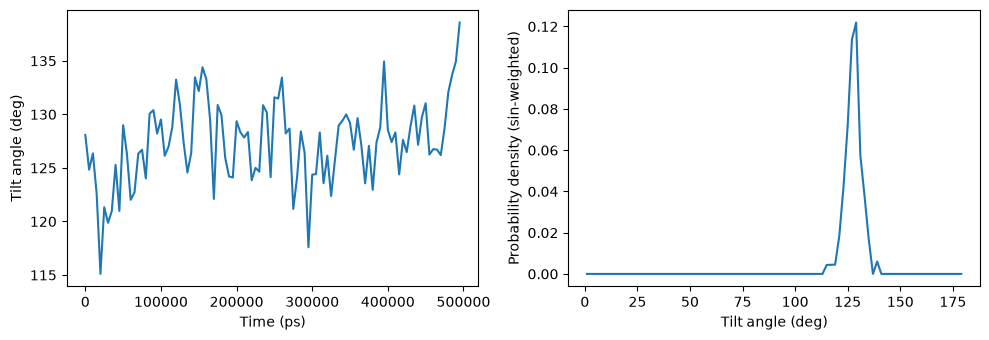

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].plot(theta_df["time_ps"], theta_df["theta_deg"])
axes[0].set_xlabel("Time (ps)")
axes[0].set_ylabel("Tilt angle (deg)")

axes[1].plot(hist_df["theta_center_deg"], hist_df["prob_density"])
axes[1].set_xlabel("Tilt angle (deg)")
axes[1].set_ylabel("Probability density (sin-weighted)")
plt.tight_layout()
plt.savefig("orientation_relative_to_membrane_normal.svg", format="svg")
plt.show()

In [18]:
def lipid_contact_enrichment_overall(universe, protein_sel, lipid_species_sel,
                                       composition, cutoff=5.0, step=1):
    """
    Overall (whole-protein) contact enrichment per lipid species.

    Parameters
    ----------
    protein_sel : str                     selection for the protein (or chain)
    lipid_species_sel : dict {name: sel}  one MDAnalysis selection string per
                                           lipid species, e.g.
                                           {"POPC": "resname POPC", "CHOL": "resname CHL1"}
    composition : dict {name: fraction}   relative abundance of each species in the
                                           bulk membrane (mole fraction or raw counts --
                                           will be renormalized to sum to 1)

    Returns
    -------
    DataFrame: lipid_species, observed_contact_fraction, bulk_mole_fraction, enrichment_index
    """
    protein = universe.select_atoms(protein_sel)
    lipid_atoms = {sp: universe.select_atoms(sel) for sp, sel in lipid_species_sel.items()}

    total_comp = sum(composition.values())
    norm_comp = {sp: composition.get(sp, 0.0) / total_comp for sp in lipid_species_sel}

    species_contact_counts = {sp: 0 for sp in lipid_species_sel}

    for ts in universe.trajectory[::step]:
        for sp, atoms in lipid_atoms.items():
            if len(atoms) == 0:
                continue
            d = distance_array(atoms.positions, protein.positions, box=universe.dimensions)
            in_contact_atoms = atoms[(d <= cutoff).any(axis=1)]
            # count unique lipid molecules (residues), not atoms, in contact this frame
            species_contact_counts[sp] += len(in_contact_atoms.residues)

    total_contacts = sum(species_contact_counts.values())

    rows = []
    for sp in lipid_species_sel:
        observed_frac = (species_contact_counts[sp] / total_contacts
                          if total_contacts > 0 else np.nan)
        bulk_frac = norm_comp[sp]
        enrichment = observed_frac / bulk_frac if bulk_frac > 0 else np.nan
        rows.append({
            "lipid_species": sp,
            "observed_contact_fraction": observed_frac,
            "bulk_mole_fraction": bulk_frac,
            "enrichment_index": enrichment,
        })
    return pd.DataFrame(rows)


def lipid_contact_enrichment_per_residue(universe, protein_sel, lipid_species_sel,
                                          composition, cutoff=5.0, step=1):
    """
    Per-residue contact probability and enrichment index for each lipid species.

    Returns
    -------
    DataFrame with one row per residue, columns:
        resid, resname, segid,
        contact_prob_<species>, enrichment_<species>   (repeated per species)
    """
    protein = universe.select_atoms(protein_sel)
    residues = protein.residues
    lipid_atoms = {sp: universe.select_atoms(sel) for sp, sel in lipid_species_sel.items()}

    total_comp = sum(composition.values())
    norm_comp = {sp: composition.get(sp, 0.0) / total_comp for sp in lipid_species_sel}

    counts = {sp: np.zeros(len(residues)) for sp in lipid_species_sel}
    n_frames = 0

    for ts in universe.trajectory[::step]:
        n_frames += 1
        for i, res in enumerate(residues):
            for sp, atoms in lipid_atoms.items():
                if len(atoms) == 0:
                    continue
                d = distance_array(res.atoms.positions, atoms.positions, box=universe.dimensions)
                if d.size and d.min() <= cutoff:
                    counts[sp][i] += 1

    rows = []
    for i, res in enumerate(residues):
        row = {"resid": res.resid, "resname": res.resname, "segid": res.segid}
        for sp in lipid_species_sel:
            p = counts[sp][i] / n_frames
            bulk_frac = norm_comp[sp]
            row[f"contact_prob_{sp}"] = p
            row[f"enrichment_{sp}"] = p / bulk_frac if bulk_frac > 0 else np.nan
        rows.append(row)

    return pd.DataFrame(rows)

In [19]:
# Bulk membrane composition -- edit to match your system
# (values can be mole fractions, percentages, or raw lipid counts -- normalized internally)
membrane_composition = {
    "DPPC": 0.24,
    "PLPC": 0.11,
    "PLPE": 0.07,
    "SOPE": 0.18,
    "SAPI": 0.06,
    "SDPI": 0.02,
    "SOPS": 0.03,
    "PSM": 0.03,
    "LSM": 0.03,
    "CHL": 0.18,
    "BMGP": 0.07,
}

lipid_species_sel = {
    "DPPC": "resname DPPC",
    "PLPC": "resname PLPC",
    "PLPE": "resname PLPE",
    "SOPE": "resname SOPE",
    "SAPI": "resname SAPI",
    "SDPI": "resname SDPI",
    "SOPS": "resname SOPS",
    "PSM": "resname PSM",
    "LSM": "resname LSM",
    "CHL": "resname CHL",
    "BMGP": "resname BMGP",
}

enrichment_overall_df = lipid_contact_enrichment_overall(
    u,
    protein_sel="segid PROA",
    lipid_species_sel=lipid_species_sel,
    composition=membrane_composition,
    cutoff=5.0,
    step=10,
)
enrichment_overall_df.to_csv("lipid_contact_enrichment_overall_chainA.csv", index=False)
enrichment_overall_df


,lipid_species,observed_contact_fraction,bulk_mole_fraction,enrichment_index
0,DPPC,0.268293,0.235294,1.140244
1,PLPC,0.151220,0.107843,1.402217
2,PLPE,0.082927,0.068627,1.208362
3,SOPE,0.175610,0.176471,0.995122
4,SAPI,0.180488,0.058824,3.068293
5,SDPI,0.000000,0.019608,0.000000
6,SOPS,0.000000,0.029412,0.000000
7,PSM,0.082927,0.029412,2.819512
8,LSM,0.004878,0.029412,0.165854
9,CHL,0.000000,0.176471,0.000000


In [20]:
enrichment_per_residue_df = lipid_contact_enrichment_per_residue(
    u,
    protein_sel="segid PROA",
    lipid_species_sel=lipid_species_sel,
    composition=membrane_composition,
    cutoff=5.0,
    step=10,
)
enrichment_per_residue_df.to_csv("lipid_contact_enrichment_per_residue_ChainA.csv", index=False)
enrichment_per_residue_df.head(10)

,resid,resname,segid,contact_prob_DPPC,enrichment_DPPC,contact_prob_PLPC,enrichment_PLPC,contact_prob_PLPE,enrichment_PLPE,contact_prob_SOPE,...,contact_prob_SOPS,enrichment_SOPS,contact_prob_PSM,enrichment_PSM,contact_prob_LSM,enrichment_LSM,contact_prob_CHL,enrichment_CHL,contact_prob_BMGP,enrichment_BMGP
0,3249,PRO,PROA,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,3250,PRO,PROA,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3251,LEU,PROA,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,3252,ALA,PROA,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,3253,ALA,PROA,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,3254,GLU,PROA,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,3255,VAL,PROA,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,3256,GLY,PROA,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,3257,MET,PROA,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,3258,ALA,PROA,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


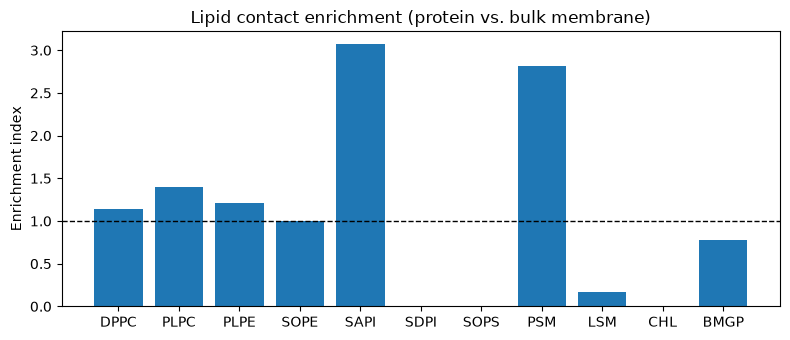

In [21]:
# Overall enrichment index per species -- dashed line at 1.0 marks "no preference"
plt.figure(figsize=(8, 3.5))
plt.bar(enrichment_overall_df["lipid_species"], enrichment_overall_df["enrichment_index"])
plt.axhline(1.0, color="k", linestyle="--", linewidth=1)
plt.ylabel("Enrichment index")
plt.title("Lipid contact enrichment (protein vs. bulk membrane)")
plt.tight_layout()
plt.savefig("Lipid contact enrichment chainA.svg", format="svg")
plt.show()

In [22]:

enrichment_overall_df = lipid_contact_enrichment_overall(
    u,
    protein_sel="segid PROB",
    lipid_species_sel=lipid_species_sel,
    composition=membrane_composition,
    cutoff=5.0,
    step=10,
)
enrichment_overall_df.to_csv("lipid_contact_enrichment_overall_chainB.csv", index=False)
enrichment_overall_df

,lipid_species,observed_contact_fraction,bulk_mole_fraction,enrichment_index
0,DPPC,0.273142,0.235294,1.160853
1,PLPC,0.118559,0.107843,1.099366
2,PLPE,0.093023,0.068627,1.355482
3,SOPE,0.192430,0.176471,1.090439
4,SAPI,0.102599,0.058824,1.744186
5,SDPI,0.005016,0.019608,0.255814
6,SOPS,0.072047,0.029412,2.449612
7,PSM,0.020976,0.029412,0.713178
8,LSM,0.063383,0.029412,2.155039
9,CHL,0.000000,0.176471,0.000000


In [23]:
enrichment_per_residue_df = lipid_contact_enrichment_per_residue(
    u,
    protein_sel="segid PROB",
    lipid_species_sel=lipid_species_sel,
    composition=membrane_composition,
    cutoff=5.0,
    step=10,
)
enrichment_per_residue_df.to_csv("lipid_contact_enrichment_per_residue_ChainB.csv", index=False)
enrichment_per_residue_df.head(10)

,resid,resname,segid,contact_prob_DPPC,enrichment_DPPC,contact_prob_PLPC,enrichment_PLPC,contact_prob_PLPE,enrichment_PLPE,contact_prob_SOPE,...,contact_prob_SOPS,enrichment_SOPS,contact_prob_PSM,enrichment_PSM,contact_prob_LSM,enrichment_LSM,contact_prob_CHL,enrichment_CHL,contact_prob_BMGP,enrichment_BMGP
0,1,MET,PROB,0.0,0.0,0.0,0.0,0.0,0.0,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2,GLY,PROB,0.0,0.0,0.0,0.0,0.0,0.0,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3,GLU,PROB,0.0,0.0,0.0,0.0,0.0,0.0,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4,SER,PROB,0.0,0.0,0.0,0.0,0.0,0.0,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5,ILE,PROB,0.0,0.0,0.0,0.0,0.0,0.0,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,6,PRO,PROB,0.0,0.0,0.0,0.0,0.0,0.0,0.02,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,7,LEU,PROB,0.0,0.0,0.0,0.0,0.0,0.0,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,8,ALA,PROB,0.0,0.0,0.0,0.0,0.0,0.0,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,9,ALA,PROB,0.0,0.0,0.0,0.0,0.0,0.0,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,10,PRO,PROB,0.0,0.0,0.0,0.0,0.0,0.0,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


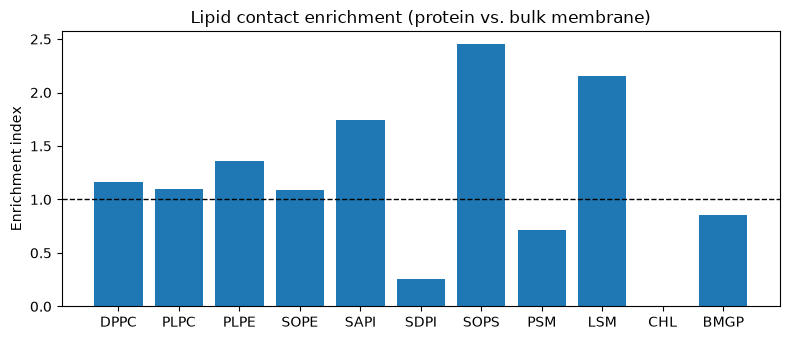

In [24]:
# Overall enrichment index per species -- dashed line at 1.0 marks "no preference"
plt.figure(figsize=(8, 3.5))
plt.bar(enrichment_overall_df["lipid_species"], enrichment_overall_df["enrichment_index"])
plt.axhline(1.0, color="k", linestyle="--", linewidth=1)
plt.ylabel("Enrichment index")
plt.title("Lipid contact enrichment (protein vs. bulk membrane)")
plt.tight_layout()
plt.savefig("Lipid contact enrichment chainB.svg", format="svg")
plt.show()

## Notes

- **Curved membranes**: replace `normal_axis` with a per-frame local normal estimated from nearby lipid headgroups (centroid + PCA, smallest-eigenvalue eigenvector) if the bilayer isn't flat.
- **PBC**: `distance_array` above is given `box=universe.dimensions`, which applies minimum-image convention automatically — no manual wrapping needed for the contact/distance calculations, unlike the raw-coordinate VMD Tcl version.
- **Performance**: the per-residue contact loop is O(residues × frames); for large systems/long trajectories, consider `MDAnalysis.analysis.distances.contact_matrix` or coarser strides.
- **Residence time units**: make sure `DT_PS` matches your actual NAMD `dcdfreq * timestep`, or the fitted tau values will be meaningless.